[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-lyman-break-stacks/notebook.ipynb)

# Does the expected Lyman-break migration appear in stacked UNCOVER photometry?

**Scientific question:** Do median broad-band flux patterns move to longer wavelengths with candidate redshift?


This notebook uses the frozen UNCOVER DR3 “SUPER” photometric catalogue for
Abell 2744. The release combines HST and JWST imaging, detects sources in a
noise-equalized F277W+F356W+F444W image, PSF-matches the photometry to F444W,
and supplies EAzY photometric-redshift posteriors. The compact repository table
contains rows with usable photometry, a passing EAzY flag, and a maximum-
likelihood redshift from 6 to 15.

That is a candidate selection, not a confirmation list. A photometric redshift
can confuse a Lyman break with dust, an emission-line boosted band, or a lower-
redshift spectral break. Abell 2744 also lenses the background and changes both
the observed brightness and the effective source-plane area. Every result below
is therefore conditional on the release photometry, templates, flags, and lens
model. The notebook measures the catalogue; it does not claim a new population
measurement or spectroscopic discovery.

## Reproducibility contract

The source is Zenodo DOI `10.5281/zenodo.11059273`, retrieved on 1 August 2026.
The upstream FITS MD5 is `baeb44ce166c920050ceb93220b12e05`. The repository
derivative preserves coordinates, broad-band fluxes and errors, redshift
posterior percentiles, flags, an image size proxy, and lensing magnification.
Fluxes are in the catalogue's native 10 nJy units (AB zeropoint 28.9). We keep
negative flux measurements when summarising stacks because clipping them would
bias faint measurements upward. Each figure is saved at publication-oriented
resolution with SciencePlots' `science` style and `no-latex` for reliable Colab
execution.

## Claim boundary

The analysis distinguishes observed quantities from derived proxies. It reports
sample sizes, selection changes, resampling intervals, or parameter stress
tests. Results may motivate a targeted check against UNCOVER DR4 spectroscopy,
but the photometric catalogue alone cannot prove a galaxy's redshift, stellar
mass, star-formation rate, chemical abundance, or physical size. Those require
spectroscopy and/or more complete forward modelling with selection functions.

## Physical idea

Neutral hydrogen absorbs rest-frame ultraviolet light blueward of Lyman-alpha.
As redshift increases, that break moves through successively redder JWST
filters. We make median, F444W-normalized observed-frame stacks in three
photometric-redshift bins. Only objects with positive F444W flux and signal to
noise above five enter this display; flux in bluer bands may remain negative
and is retained. The normalization compares spectral shape rather than apparent
brightness. It cannot reveal chemical constituents because these are wide
filters, and emission lines, dust, and redshift-template assumptions remain
mixed together.

In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS = {"navy": "#071426", "cyan": "#39c6d4", "gold": "#e3a82b",
          "coral": "#e66b55", "violet": "#7357c7", "green": "#3b9b77"}
RNG = np.random.default_rng(1999)

In [2]:
LOCAL = Path("../../data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv")
RAW = "https://raw.githubusercontent.com/Biswajit1999/daily-astro-notebooks/master/data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv"
if not LOCAL.exists():
    LOCAL = Path("uncover_dr3_z6_candidates.csv")
    if not LOCAL.exists():
        urllib.request.urlretrieve(RAW, LOCAL)
data = pd.read_csv(LOCAL)
print(f"Loaded {len(data):,} quality-flagged photometric candidates")
print(f"Sky footprint: RA {data.ra.min():.4f}–{data.ra.max():.4f} deg; Dec {data.dec.min():.4f}–{data.dec.max():.4f} deg")

Loaded 4,731 quality-flagged photometric candidates
Sky footprint: RA 3.4448–3.6699 deg; Dec -30.4673–-30.2914 deg


In [3]:
bands=np.array(["f090w","f115w","f150w","f200w","f277w","f356w","f444w"])
waves=np.array([0.90,1.15,1.50,2.00,2.77,3.56,4.44])
base=data[(data.f_f444w>0)&(data.f_f444w/data.e_f444w>=5)].copy()
z_bins=[(6,7),(7,9),(9,12)]; rows=[]
for lo,hi in z_bins:
    sample=base[base.z_phot.between(lo,hi,inclusive="left")]
    for band,wave in zip(bands,waves):
        ratio=sample[f"f_{band}"]/sample.f_f444w
        rows.append([lo,hi,band,wave,len(sample),np.nanmedian(ratio),
                     np.nanpercentile(ratio,[16,84])[0],np.nanpercentile(ratio,[16,84])[1]])
stack=pd.DataFrame(rows,columns=["z_low","z_high","band","wavelength_um","n","median_fnu_over_f444w","p16","p84"])
stack.to_csv("median_sed_stacks.csv",index=False)
print(stack.groupby(["z_low","z_high"]).n.first())

z_low  z_high
6      7         558
7      9         432
9      12        147
Name: n, dtype: int64


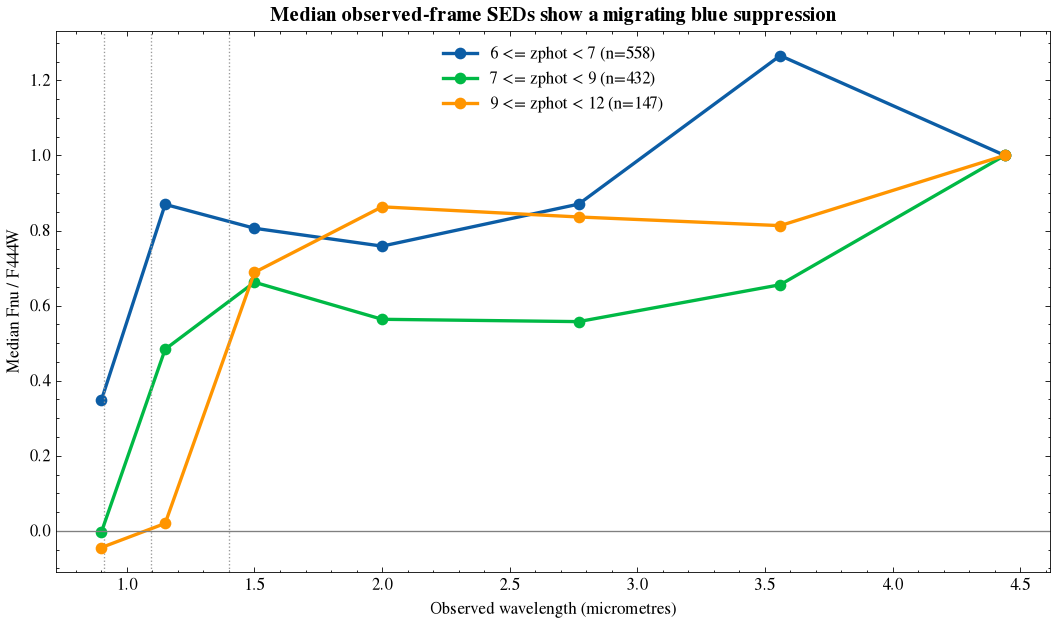

In [4]:
fig,ax=plt.subplots(figsize=(9,5.4))
for (lo,hi),group in stack.groupby(["z_low","z_high"]):
    ax.plot(group.wavelength_um,group.median_fnu_over_f444w,"o-",lw=2,label=f"{lo} <= zphot < {hi} (n={group.n.iloc[0]:,})")
    break_um=.1216*(1+(lo+hi)/2); ax.axvline(break_um,color="0.6",ls=":",lw=.8)
ax.axhline(0,color="0.5",lw=.8); ax.set(xlabel="Observed wavelength (micrometres)",ylabel="Median Fnu / F444W",
title="Median observed-frame SEDs show a migrating blue suppression"); ax.legend(); fig.tight_layout()
fig.savefig("lyman_break_median_stacks.png"); plt.show()

## A direct colour stress test

For each redshift range we pair a band expected to lie nearer or blueward of
the break with a redder detection band. Medians are bootstrapped over objects.
The ratio is deliberately called a suppression proxy, not a break amplitude,
because filter transmission curves are not integrated here and the selection
already used the same photometry. The test is therefore descriptive and partly
circular; spectroscopy would provide independent validation.

In [5]:
pairs=[(6,8,"f090w","f200w"),(8,10,"f115w","f277w"),(10,12,"f150w","f356w")]
drop=[]
for lo,hi,blue,red in pairs:
    s=data[data.z_phot.between(lo,hi,inclusive="left") & (data[f"f_{red}"]>0) & (data[f"f_{red}"]/data[f"e_{red}"]>=5)]
    values=(s[f"f_{blue}"]/s[f"f_{red}"]).replace([np.inf,-np.inf],np.nan).dropna().to_numpy()
    boots=np.array([np.median(RNG.choice(values,len(values),replace=True)) for _ in range(1500)])
    q=np.percentile(boots,[2.5,50,97.5]); drop.append([lo,hi,blue,red,len(values),*q])
drop=pd.DataFrame(drop,columns=["z_low","z_high","blue_band","red_band","n","ratio_low","ratio_median","ratio_high"])
drop.to_csv("dropout_ratio_summary.csv",index=False); print(drop.to_string(index=False))

 z_low  z_high blue_band red_band   n  ratio_low  ratio_median  ratio_high
     6       8     f090w    f200w 546   0.326977      0.362331    0.390133
     8      10     f115w    f277w 164   0.255170      0.319436    0.360725
    10      12     f150w    f356w  98   0.663170      0.753581    0.813693


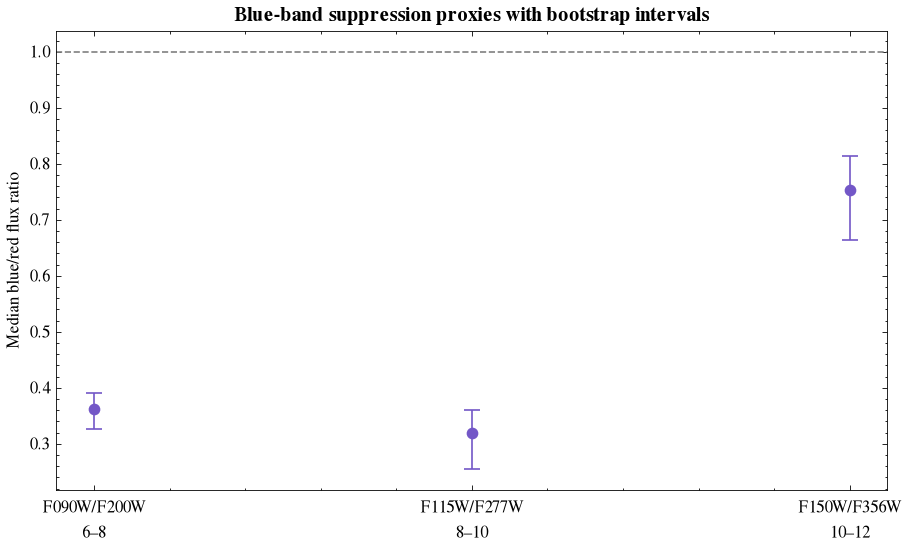

In [6]:
fig,ax=plt.subplots(figsize=(7.8,4.8)); labels=[]
for i,r in drop.iterrows():
    ax.errorbar(i,r.ratio_median,yerr=[[r.ratio_median-r.ratio_low],[r.ratio_high-r.ratio_median]],fmt="o",capsize=5,color=COLORS["violet"])
    labels.append(f"{r.blue_band.upper()}/{r.red_band.upper()}\n{r.z_low:g}–{r.z_high:g}")
ax.set_xticks(range(len(labels)),labels); ax.axhline(1,color="0.5",ls="--")
ax.set(ylabel="Median blue/red flux ratio",title="Blue-band suppression proxies with bootstrap intervals")
fig.tight_layout(); fig.savefig("dropout_ratio_bootstrap.png"); plt.show()

In [7]:
FOLDER="2026-08-01-uncover-lyman-break-stacks"; TITLE="Does the Lyman-break migration appear in stacked UNCOVER photometry?"
QUESTION="Do median broad-band flux patterns move to longer wavelengths with candidate redshift?"; SAMPLE_SIZE=len(base)
RESULTS=[f"{len(base):,} candidates pass the F444W signal-to-noise display cut",f"Median blue/red ratios span {drop.ratio_median.min():.3f}–{drop.ratio_median.max():.3f} across the three bins"]
VALIDATION="The wavelength of blue suppression shifts redward across bins as expected for a Lyman break, but this is not independent of the photometric-redshift fit."
FIGURES=["lyman_break_median_stacks.png","dropout_ratio_bootstrap.png"]; ARTIFACTS=["median_sed_stacks.csv","dropout_ratio_summary.csv"]
QUALITY_CHECKS=[{"name":"negative blue flux retained","status":"passed"},{"name":"red-band S/N >= 5","status":"passed"},{"name":"bootstrap intervals","status":"passed"}]
LIMITATIONS=["Broad-band stacks cannot identify chemical abundances.","The colour check reuses photometry that informed z_phot."]

## References and next validation

- Suess et al. (2024), UNCOVER Data Release 3 photometric catalogue.
- Weaver et al. (2024), MegaScience and UNCOVER imaging catalogue methods.
- Bezanson et al. (2024), UNCOVER survey design and public data.
- Furtak et al. (2023), Abell 2744 lens model.
- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec spectra and secure redshifts.

UNCOVER DR4.1 reports 409 secure or solid spectroscopic redshifts among 553
reduced targets and provides an updated v2.0 lens model. A strong follow-up is
to row-match the DR3 IDs to those products, remeasure the photometric-redshift
outlier rate, and replace approximate lens corrections used here. The notebook
is deliberately frozen to one internally consistent public photometric release
so that later comparisons are explicit rather than silently mixing versions.

In [8]:
record = {
    "id": FOLDER,
    "title": TITLE,
    "archive": "UNCOVER / MAST",
    "date": "2026-08-01",
    "question": QUESTION,
    "sample_size": int(SAMPLE_SIZE),
    "results": RESULTS,
    "validation": VALIDATION,
    "notebook": f"mast/{FOLDER}/notebook.ipynb",
    "hero": f"mast/{FOLDER}/{FIGURES[0]}",
    "figures": [f"mast/{FOLDER}/{name}" for name in FIGURES],
    "research_level": "Exploration",
    "claim_type": "Photometric candidate analysis",
    "provenance": [
        "UNCOVER DR3 SUPER catalog, Zenodo DOI 10.5281/zenodo.11059273",
        "Upstream MD5 baeb44ce166c920050ceb93220b12e05",
        "Selection: use_phot=1, flag_eazy=1, 6 <= z_phot < 15",
    ],
    "artifacts": [f"mast/{FOLDER}/{name}" for name in ARTIFACTS],
    "quality_checks": QUALITY_CHECKS,
    "limitations": LIMITATIONS,
}
Path("result.json").write_text(json.dumps(record, indent=2) + "\n")
print("Saved machine-readable scientific audit:", Path("result.json").resolve())

Saved machine-readable scientific audit: /workspace/scratch/20efe8222c82/daily-astro-stage9/mast/2026-08-01-uncover-lyman-break-stacks/result.json
